# Bank Customer Churn Prediction

The aim of this project to analyze the bank customer's demographics and financial
information which inculdes customer's age, gender. country, credit score, balance and
many others to predict whether the customer will leave the bank or not

In [1]:
# import the libraries 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# loading the datasets
df = pd.read_csv("churn.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### Data Preprocessing 1

In [3]:
# checking the shape of the data 
df.shape

(10000, 14)

Dropping the unecessary columns - RowNumber, CustomerID, Surname

In [4]:
df.drop(['RowNumber', "CustomerId", "Surname"], axis=1, inplace=True)

In [5]:
df.shape

(10000, 11)

Checking the null values 

In [6]:
df.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Checking the datatypes of the columns

In [7]:
df.dtypes

CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

checking the duplicate values

In [8]:
df.duplicated().sum()

0

Renaming the column "Exited" to "Churn"

In [9]:
df.rename(columns= {"Exited": "Churn"}, inplace=True)

In [10]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Churn
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [11]:
# Descriptive statistics

df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Churn
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


# EDA

In the exploratory data analysis, I will be looking at the distribution of the data, the
coorelation between features and the target variable and the relationship between the
features and the target variable. I will start by looking at the distribution of the data,
followed by the relationship between the features and the target variable.

Pie chart for customer churn

In [16]:
df.Churn.value_counts()

Churn
0    7963
1    2037
Name: count, dtype: int64

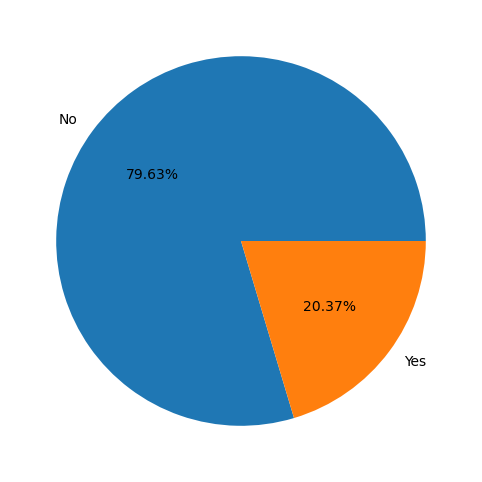

In [17]:
plt.figure(figsize=(10,6))
plt.pie(df['Churn'].value_counts(), labels=[ "No", "Yes"],autopct='%1.2f%%')
plt.show()

The pie chart clearly visulaizes the customer churn in the dataset. The majority of the
customers in the dataset continue to use the serivces of the bank with only 20.4% of the
customers churning.

#### Gender

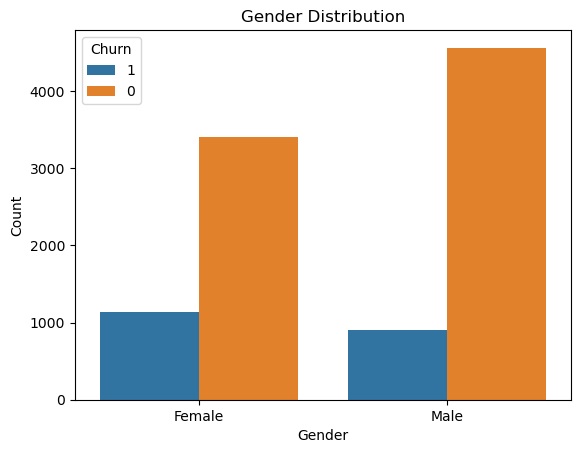

In [22]:
# gender and customer churn

sns.countplot(x = "Gender", data=df, hue=df['Churn'].astype(str))
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

As shown in the graph, majority of the customers are male. But upon looking at the
customer churn, we can see that females have more tendency to churn as compared to
males. However there is not much difference between the churn count of the two
genders so we cannot have a hypothesis regarding the customer churn based on the
gender of the customer.


### Age Distribution

C:\Users\memun\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Age', ylabel='Count'>

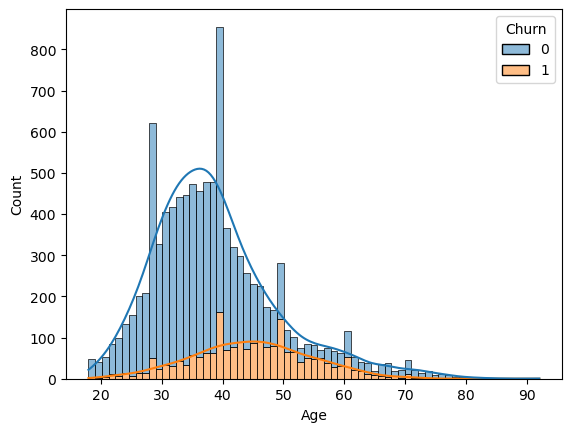

In [24]:
#histogram for age distribution 
sns.histplot(data=df , x='Age', hue='Churn', multiple='stack', kde=True)

This histtogram visualizes the age distribution and the churn count of the customers. The
majority of the customers are from age group 30-40 years old. However the customer
churn count is highest for the customersof age 40 and 50. In addition to that customers
from age group 20-25 years old count for the lowest churn count. Therefore, age plays a
significant role in customer churn, where late adults are more likely to churn as
compared to young adults with minimal churn count.


#### Credit Score

<Axes: xlabel='Churn', ylabel='CreditScore'>

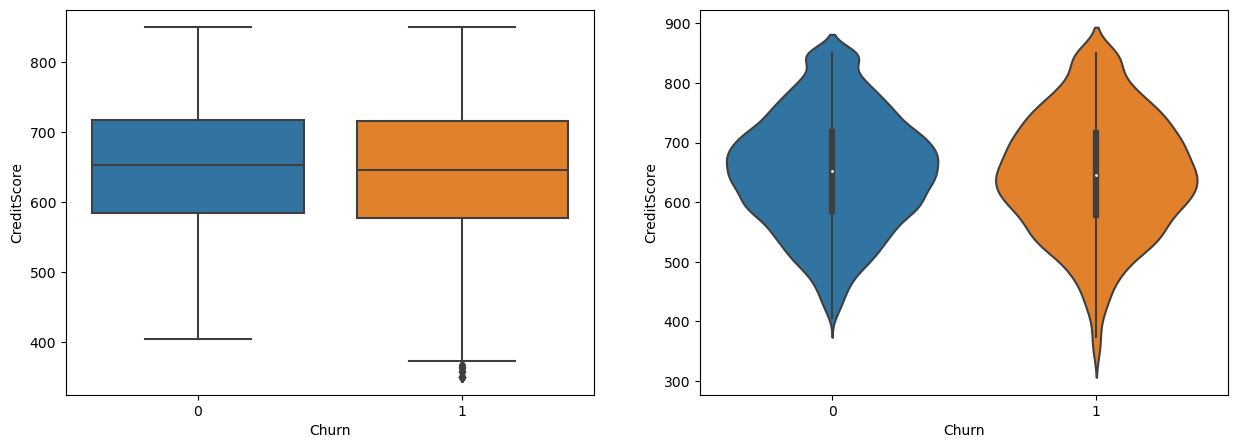

In [26]:
fig, ax = plt.subplots(1,2, figsize=(15,5))
sns.boxplot(x="Churn", y="CreditScore", data=df, ax=ax[0])
sns.violinplot(x="Churn", y="CreditScore", data=df, ax=ax[1])

The boxplot and violinplot shows the distribution of curstomer's credit score along with
their churn. In the boxplot, the median of both the churn and non churn customers are almost same. In addition to that, the shape of violinplot is also similar for both the churn
and non churn customers. However some churn customers have low credit score, but on
the whole, the credit score is not a good indicator of churn.


#### Customer Location

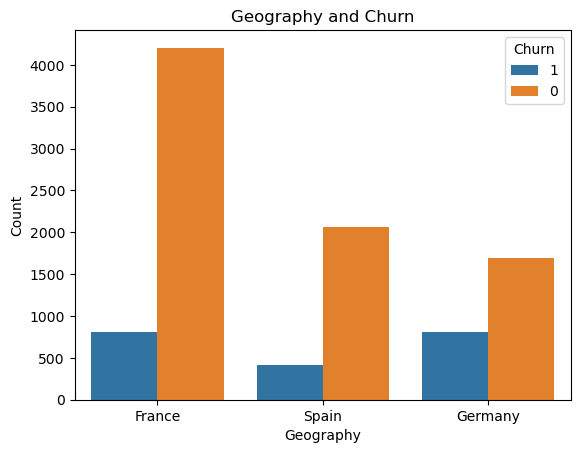

In [28]:
sns.countplot(x="Geography", hue = df["Churn"].astype(str), data=df)
plt.title("Geography and Churn")
plt.xlabel("Geography")
plt.ylabel("Count")
plt.show()

This graphs shows the number of customers from the their repective countries aling with
their churn count. Majority of the customers are from France, followed by Spain and
Germany. However in contrast to that Germany has the highest number of customer curn
followed by France and Spain. From this we can infer that German customers are more
likely to churn than the customers from other countries.


#### Tenure

<Axes: xlabel='Tenure', ylabel='count'>

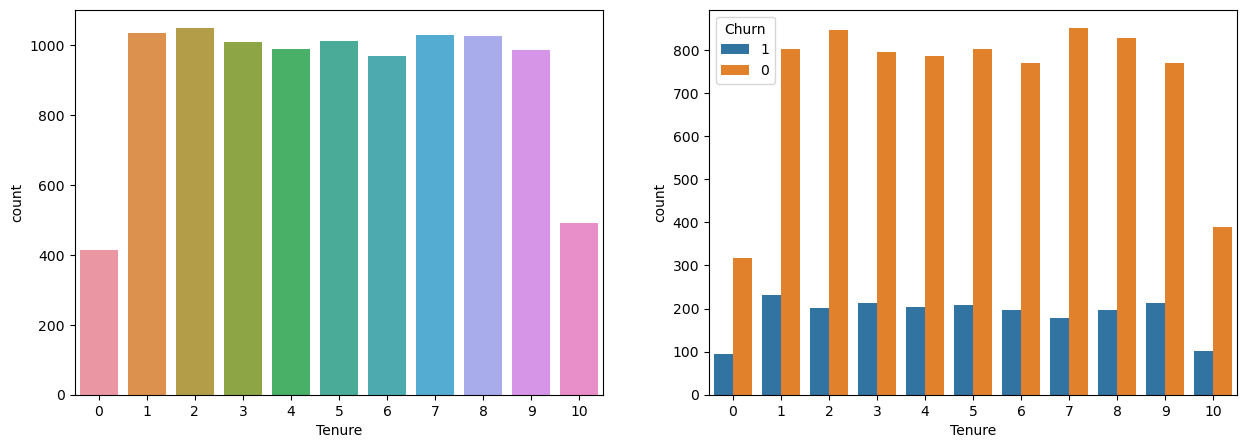

In [30]:
fig, ax = plt.subplots(1,2, figsize=(15,5))
sns.countplot(x="Tenure", data = df, ax=ax[0])
sns.countplot(x="Tenure", hue=df["Churn"].astype(str), data = df, ax=ax[1])

Tensure refers to the time (in years) that a customer has been a client of the bank.
Majority of the customers in the dataset have a tenure between 1-9 years, having equal
distribution among them. There are very few customers with a tenure of less than 1 years
or more than 9 years. Looking at the churn of these customers based on their tenure, it
can be observed that customers with tenure 1-9 years have higher churn count with
maximum in customers with 1 year tenure followed those with 9 year tenure. However
customers more than 9 years on tenure counts for the least churn. This is because the
customers with higher tenure are more loyal to the bank and less likely to churn.